### Imports

In [4]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

from collections import defaultdict
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

### Environment Creation

In [7]:
env = gym.make("Blackjack-v1", sab = True)
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space: Discrete(2)


### Epsilon Schedules

In [8]:
def constant_epsilon(epsilon_value):
    def schedule(episode):
        return epsilon_value
    return schedule

def linear_decay_epsilon(start=1.0, end=0.05, decay_episodes=500_000):
    def schedule(episode):
        fraction = min(episode / decay_episodes, 1.0)
        return start + fraction * (end -  start)
    return schedule

def exponential_decay_epsilon(start=1.0, end=0.05, decay_rate=0.99999):
    def schedule(episode):
        return max(end, start * (decay_rate ** episode))
    return schedule



### Epsilon Greedy Policy

In [10]:
def epsilon_greedy_action(state, Q, epsilon, rng):
    if rng.random() < epsilon:
        return int(rng.integers(0,2))
    return int(np.argmax(Q[state]))

### Episode Generation

In [9]:
def generate_episode(env, Q, epsilon, rng):
    state, info = env.reset()
    trajectory = []
    terminated = False
    truncated = False
    while not terminated:
        action = epsilon_greedy_action(state=state, Q=Q, epsilon=epsilon,rng=rng)
        next_state, reward, terminated, truncated, info = env.step(action)
        trajectory.append((state, action, reward))
        state = next_state
        if truncated:
            break
    return trajectory

### First Visit Monte Carlo Control

In [11]:
def first_visit_mc_control_blackjack(
    num_episodes=500_000,
    gamma=1.0,
    epsilon_schedule=constant_epsilon(0.1),
    seed=42,
    report_every=50_000
):

    env = gym.make("Blackjack-v1", sab=True)
    rng = np.random.default_rng(seed)

    Q = defaultdict(lambda: np.zeros(2, dtype=np.float64))

    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)

    episode_returns = np.zeros(num_episodes, dtype=np.float64)
    epsilons = np.zeros(num_episodes, dtype=np.float64)

    for episode_idx in range(num_episodes):
        epsilon = epsilon_schedule(episode_idx)
        epsilons[episode_idx] = epsilon

        trajectory = generate_episode(env, Q, epsilon, rng)

        episode_returns[episode_idx] = sum([step[2] for step in trajectory])

        rewards = np.array([step[2] for step in trajectory], dtype=np.float64)

        G_values = np.zeros(len(rewards), dtype=np.float64)
        G = 0.0

        for t in reversed(range(len(rewards))):
            G = rewards[t] + gamma * G
            G_values[t] = G

        visited_state_actions = set()

        for t, (state, action, reward) in enumerate(trajectory):
            state_action = (state, action)

            if state_action not in visited_state_actions:
                visited_state_actions.add(state_action)

                G_t = G_values[t]

                returns_sum[state_action] += G_t
                returns_count[state_action] += 1

                Q[state][action] = (
                    returns_sum[state_action] / returns_count[state_action]
                )

        if report_every is not None and (episode_idx + 1) % report_every == 0:
            avg_recent_return = np.mean(episode_returns[max(0, episode_idx - 9999):episode_idx + 1])
            print(
                f"Episode {episode_idx + 1:,} | "
                f"Epsilon: {epsilon:.4f} | "
                f"Recent Avg Return: {avg_recent_return:.4f}"
            )

    env.close()

    return Q, episode_returns, epsilons

### Training the Model

In [12]:
N_EPISODES = 500_000
Q_main, returns_main, eps_main = first_visit_mc_control_blackjack(
    num_episodes=N_EPISODES,
    gamma=1.0,
    epsilon_schedule=constant_epsilon(0.1),
    seed = 42,
    report_every=50_000
)

Episode 50,000 | Epsilon: 0.1000 | Recent Avg Return: -0.1104
Episode 100,000 | Epsilon: 0.1000 | Recent Avg Return: -0.1008
Episode 150,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0853
Episode 200,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0828
Episode 250,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0911
Episode 300,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0990
Episode 350,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0692
Episode 400,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0789
Episode 450,000 | Epsilon: 0.1000 | Recent Avg Return: -0.1008
Episode 500,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0856


### Converting Q(s, a) to V(s) and Policy

In [13]:
def get_value_function(Q):
    V = defaultdict(float)
    for state,action_values in Q.items():
        V[state] = np.max(action_values)
    return V

def get_greedy_policy(Q):
    policy = {}
    for state, action_values in Q.items():
        policy[state] = int(np.argmax(action_values))
    return  policy

V_main = get_value_function(Q_main)
policy_main = get_greedy_policy(Q_main)
print(V_main)
print(policy_main)

defaultdict(<class 'float'>, {(11, 2, 0): np.float64(0.15700359158542843), (14, 5, 0): np.float64(-0.1555673947789025), (9, 5, 0): np.float64(0.10174418604651163), (14, 2, 0): np.float64(-0.28194233687405157), (12, 10, 0): np.float64(-0.44279598897554684), (8, 10, 0): np.float64(-0.3249835201054713), (14, 10, 0): np.float64(-0.5169733683849583), (11, 10, 0): np.float64(0.014356375919893836), (14, 3, 0): np.float64(-0.22842363190852163), (7, 6, 0): np.float64(-0.020766773162939296), (20, 3, 1): np.float64(0.6167664670658682), (12, 7, 0): np.float64(-0.22709923664122136), (21, 10, 1): np.float64(0.9179682980446604), (10, 7, 0): np.float64(0.23893303064699206), (21, 4, 1): np.float64(0.9798850574712644), (18, 9, 0): np.float64(-0.1899972059234423), (16, 9, 0): np.float64(-0.5215277777777778), (5, 6, 0): np.float64(-0.13024282560706402), (18, 7, 1): np.float64(0.39941690962099125), (13, 10, 0): np.float64(-0.4849176485102708), (10, 2, 0): np.float64(0.11291291291291292), (18, 10, 0): np.fl

### Value Grids For Plotting

In [15]:
def buld_value_grid(V, usable_ace):
    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)
    grid = np.zeros((len(player_sums), len(dealer_cards)))
    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (player_sum, dealer_card, usable_ace)
            grid[i, j] = V[state]
    return player_sums, dealer_cards, grid

### Plots from Learned Values

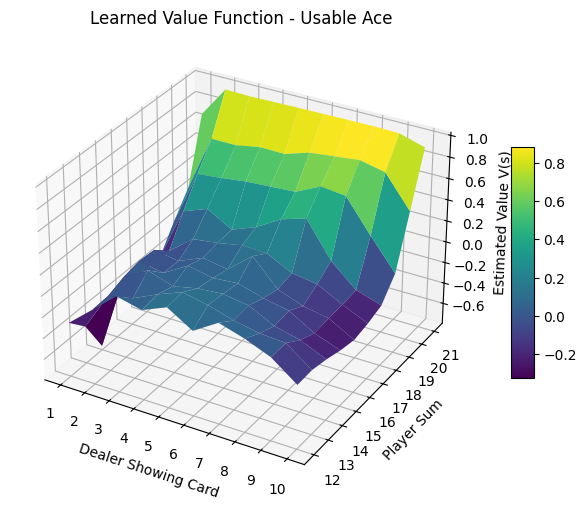

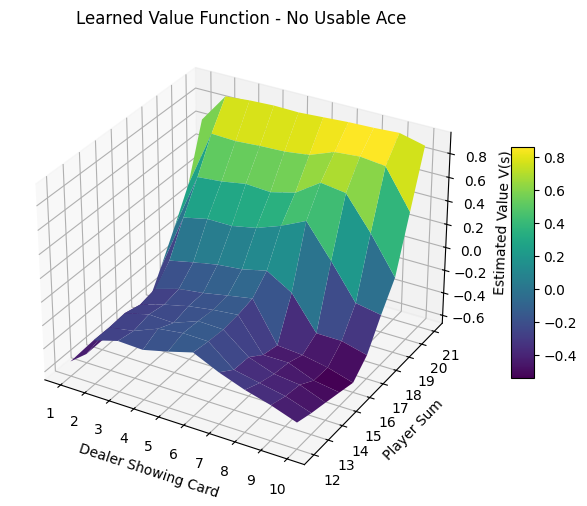

In [16]:
def plot_value_surface(V, usable_ace, title):
    player_sums, dealer_cards, value_grid = buld_value_grid(V, usable_ace=usable_ace)
    X,Y = np.meshgrid(dealer_cards, player_sums)
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection = "3d")
    surface = ax.plot_surface(X,Y, value_grid, cmap = "viridis", edgecolor = "none")
    ax.set_title(title)
    ax.set_xlabel("Dealer Showing Card")
    ax.set_ylabel("Player Sum")
    ax.set_zlabel("Estimated Value V(s)")
    ax.set_xticks(dealer_cards)
    ax.set_yticks(player_sums)
    fig.colorbar(surface,shrink = 0.5, aspect = 10)
    plt.show()

plot_value_surface(V_main, usable_ace=True, title = "Learned Value Function - Usable Ace")
plot_value_surface(V_main, usable_ace=False, title="Learned Value Function - No Usable Ace")


### Policy Grid Heatmap

In [17]:
def build_policy_grid(policy, usable_ace):
    player_sums = np.arange(12,22)
    dealer_cards = np.arange(1, 11)
    grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)
    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (player_sum, dealer_card, usable_ace)
            grid[i,j] = policy.get(state,1)
    return player_sums, dealer_cards, grid

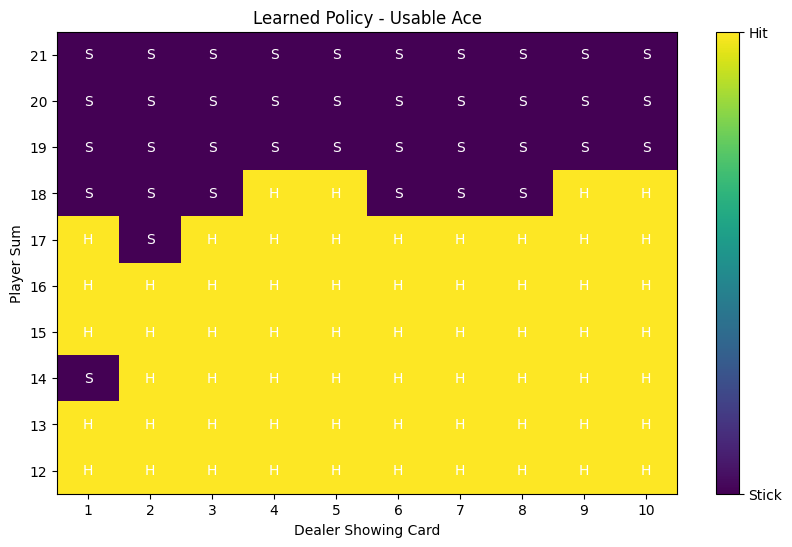

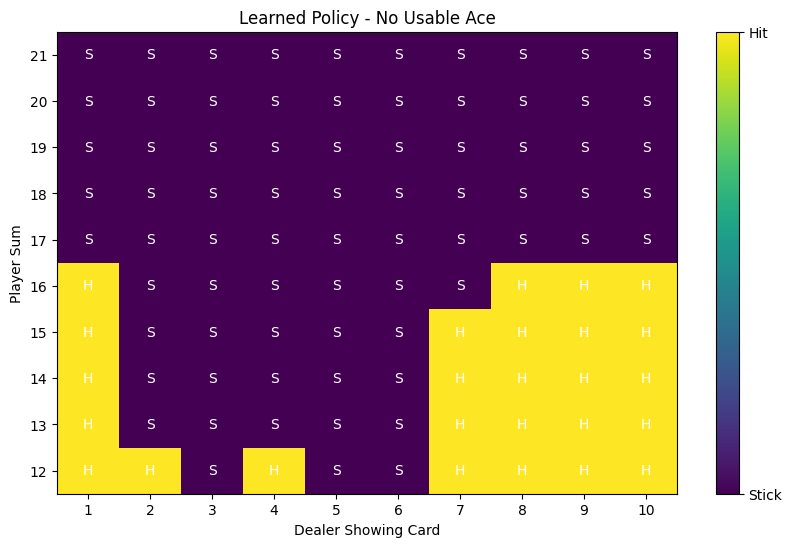

In [18]:
def plot_policy(policy, usable_ace, title):
    
    player_sums, dealer_cards, policy_grid = build_policy_grid(policy, usable_ace)
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(policy_grid, origin="lower", aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("Dealer Showing Card")
    ax.set_ylabel("Player Sum")
    ax.set_xticks(np.arange(len(dealer_cards)))
    ax.set_xticklabels(dealer_cards)
    ax.set_yticks(np.arange(len(player_sums)))
    ax.set_yticklabels(player_sums)
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(["Stick", "Hit"])

    for i in range(policy_grid.shape[0]):
        for j in range(policy_grid.shape[1]):
            action_text = "H" if policy_grid[i, j] == 1 else "S"
            ax.text(j, i, action_text, ha="center", va="center", color="white")

    plt.show()

plot_policy(policy_main, usable_ace=True, title="Learned Policy - Usable Ace")
plot_policy(policy_main, usable_ace=False, title="Learned Policy - No Usable Ace")

### Learning Curve with Smoothing

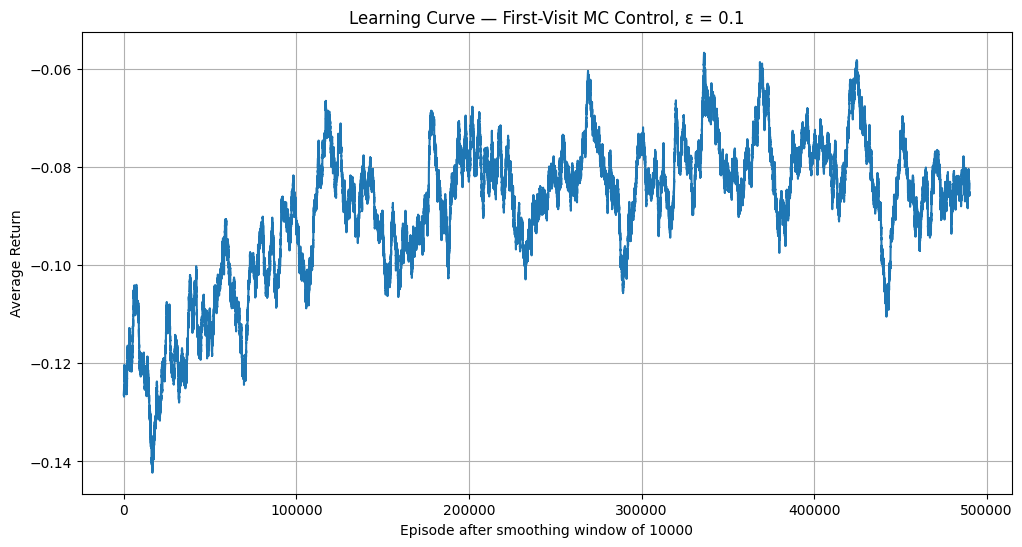

In [19]:
def moving_average(data, window_size=10_000):
    data = np.asarray(data, dtype=np.float64)
    if len(data) < window_size:
        return data
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode="valid")

def plot_learning_curve(episode_returns, window_size=10_000, title="Learning Curve"):
    smoothed_returns = moving_average(episode_returns, window_size)
    plt.figure(figsize=(12, 6))
    plt.plot(smoothed_returns)
    plt.title(title)
    plt.xlabel(f"Episode after smoothing window of {window_size}")
    plt.ylabel("Average Return")
    plt.grid(True)
    plt.show()

plot_learning_curve(
    returns_main,
    window_size=10_000,
    title="Learning Curve — First-Visit MC Control, ε = 0.1"
)

### Basic Blackjack Strategy Comparator

In [20]:
def basic_blackjack_strategy(player_sum, dealer_card, usable_ace):
    if usable_ace:
        if player_sum >= 19:
            return 0

        if player_sum == 18:
            if dealer_card in [2, 7, 8]:
                return 0
            else:
                return 1

        return 1

    else:
        if player_sum >= 17:
            return 0

        if 13 <= player_sum <= 16:
            if 2 <= dealer_card <= 6:
                return 0
            else:
                return 1

        if player_sum == 12:
            if 4 <= dealer_card <= 6:
                return 0
            else:
                return 1

        return 1

### Comparing Learned Policy with Basic Strategy

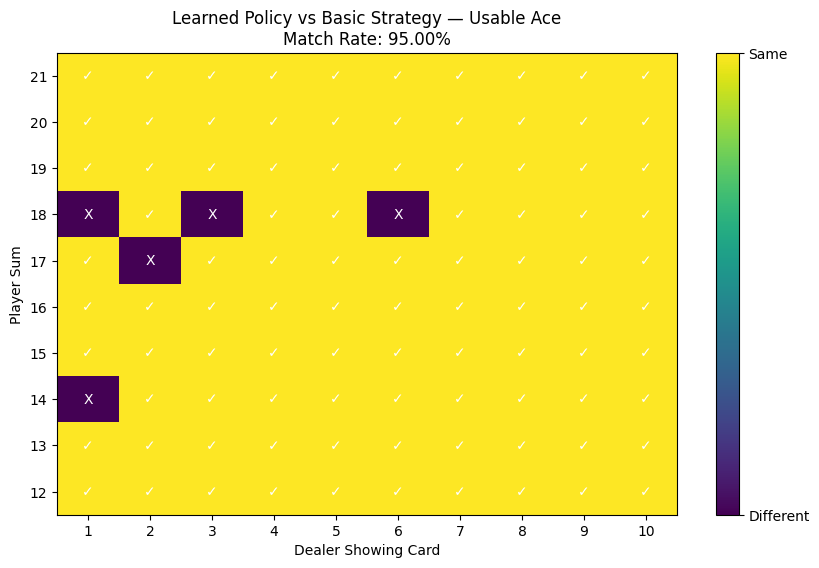

Learned Policy vs Basic Strategy — Usable Ace match rate: 95.00%


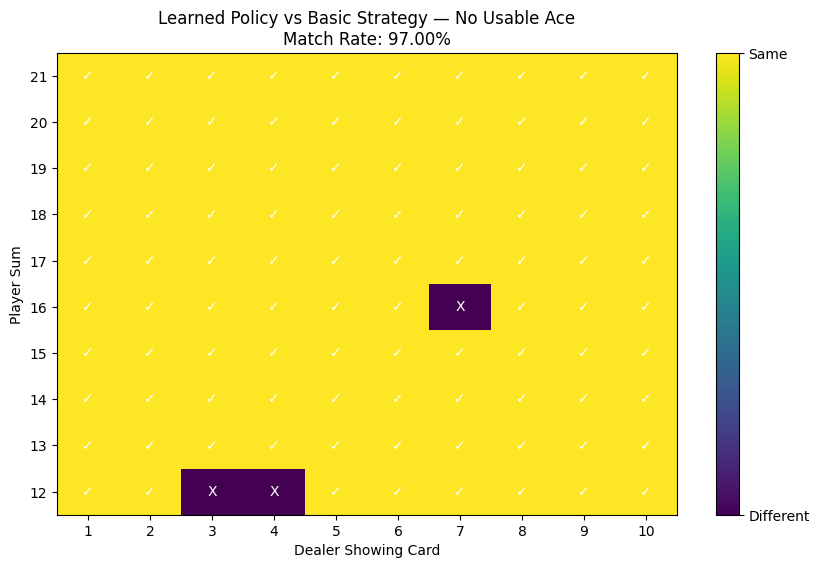

Learned Policy vs Basic Strategy — No Usable Ace match rate: 97.00%


In [21]:
def compare_policy_to_basic(policy, usable_ace):

    player_sums = np.arange(12, 22)
    dealer_cards = np.arange(1, 11)

    learned_grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)
    basic_grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)
    match_grid = np.zeros((len(player_sums), len(dealer_cards)), dtype=int)

    for i, player_sum in enumerate(player_sums):
        for j, dealer_card in enumerate(dealer_cards):
            state = (player_sum, dealer_card, usable_ace)

            learned_action = policy.get(state, 1)
            basic_action = basic_blackjack_strategy(
                player_sum,
                dealer_card,
                usable_ace
            )

            learned_grid[i, j] = learned_action
            basic_grid[i, j] = basic_action
            match_grid[i, j] = int(learned_action == basic_action)

    match_rate = np.mean(match_grid)

    return player_sums, dealer_cards, learned_grid, basic_grid, match_grid, match_rate


def plot_policy_comparison(policy, usable_ace, title):
    
    player_sums, dealer_cards, learned_grid, basic_grid, match_grid, match_rate = (
        compare_policy_to_basic(policy, usable_ace)
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    im = ax.imshow(match_grid, origin="lower", aspect="auto")

    ax.set_title(f"{title}\nMatch Rate: {match_rate:.2%}")
    ax.set_xlabel("Dealer Showing Card")
    ax.set_ylabel("Player Sum")

    ax.set_xticks(np.arange(len(dealer_cards)))
    ax.set_xticklabels(dealer_cards)

    ax.set_yticks(np.arange(len(player_sums)))
    ax.set_yticklabels(player_sums)

    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.ax.set_yticklabels(["Different", "Same"])

    for i in range(match_grid.shape[0]):
        for j in range(match_grid.shape[1]):
            text = "✓" if match_grid[i, j] == 1 else "X"
            ax.text(j, i, text, ha="center", va="center", color="white")

    plt.show()

    print(f"{title} match rate: {match_rate:.2%}")


plot_policy_comparison(
    policy_main,
    usable_ace=True,
    title="Learned Policy vs Basic Strategy — Usable Ace"
)

plot_policy_comparison(
    policy_main,
    usable_ace=False,
    title="Learned Policy vs Basic Strategy — No Usable Ace"
)

### Epsilon Experiments

In [22]:
epsilon_experiments = {
    "Constant ε = 0.01": constant_epsilon(0.01),
    "Constant ε = 0.10": constant_epsilon(0.10),
    "Constant ε = 0.30": constant_epsilon(0.30),
    "Linear Decay ε: 1.0 → 0.05": linear_decay_epsilon(
        start=1.0,
        end=0.05,
        decay_episodes=N_EPISODES
    ),
    "Exponential Decay ε: 1.0 → 0.05": exponential_decay_epsilon(
        start=1.0,
        end=0.05,
        decay_rate=0.99999
    )
}

In [23]:
experiment_results = {}

for experiment_name, eps_schedule in epsilon_experiments.items():
    print("\n" + "=" * 70)
    print(f"Training: {experiment_name}")
    print("=" * 70)

    Q_exp, returns_exp, eps_exp = first_visit_mc_control_blackjack(
        num_episodes=N_EPISODES,
        gamma=1.0,
        epsilon_schedule=eps_schedule,
        seed=42,
        report_every=100_000
    )

    experiment_results[experiment_name] = {
        "Q": Q_exp,
        "returns": returns_exp,
        "epsilons": eps_exp,
        "V": get_value_function(Q_exp),
        "policy": get_greedy_policy(Q_exp)
    }


Training: Constant ε = 0.01
Episode 100,000 | Epsilon: 0.0100 | Recent Avg Return: -0.0895
Episode 200,000 | Epsilon: 0.0100 | Recent Avg Return: -0.0941
Episode 300,000 | Epsilon: 0.0100 | Recent Avg Return: -0.0784
Episode 400,000 | Epsilon: 0.0100 | Recent Avg Return: -0.0712
Episode 500,000 | Epsilon: 0.0100 | Recent Avg Return: -0.0792

Training: Constant ε = 0.10
Episode 100,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0745
Episode 200,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0726
Episode 300,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0885
Episode 400,000 | Epsilon: 0.1000 | Recent Avg Return: -0.0792
Episode 500,000 | Epsilon: 0.1000 | Recent Avg Return: -0.1007

Training: Constant ε = 0.30
Episode 100,000 | Epsilon: 0.3000 | Recent Avg Return: -0.1553
Episode 200,000 | Epsilon: 0.3000 | Recent Avg Return: -0.1526
Episode 300,000 | Epsilon: 0.3000 | Recent Avg Return: -0.1666
Episode 400,000 | Epsilon: 0.3000 | Recent Avg Return: -0.1473
Episode 500,000 | Epsilon: 0.30

### Plotting Epsilon Schedules And Comparing Learning Curves Across Epsilon Strategies

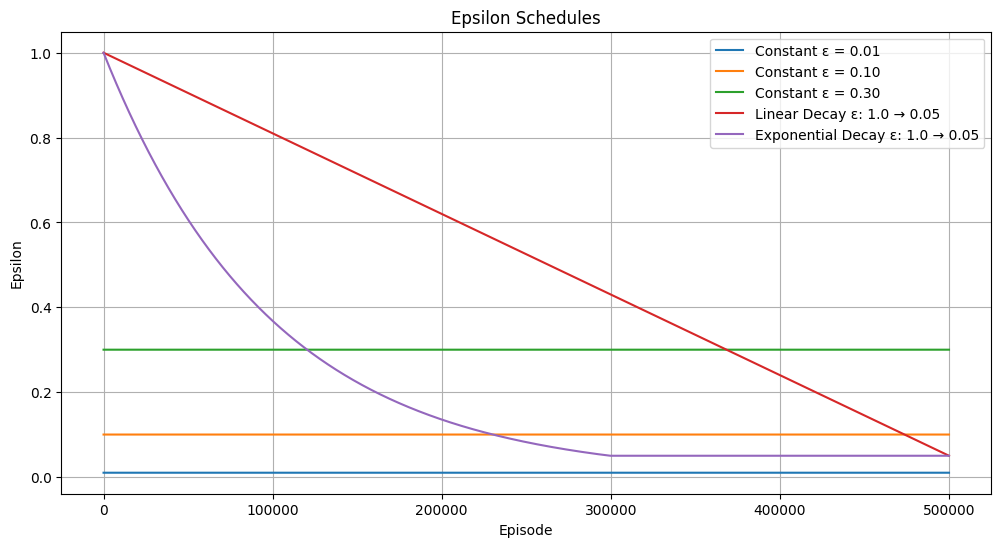

In [24]:
plt.figure(figsize=(12, 6))

for experiment_name, result in experiment_results.items():
    plt.plot(result["epsilons"], label=experiment_name)

plt.title("Epsilon Schedules")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.legend()
plt.grid(True)
plt.show()

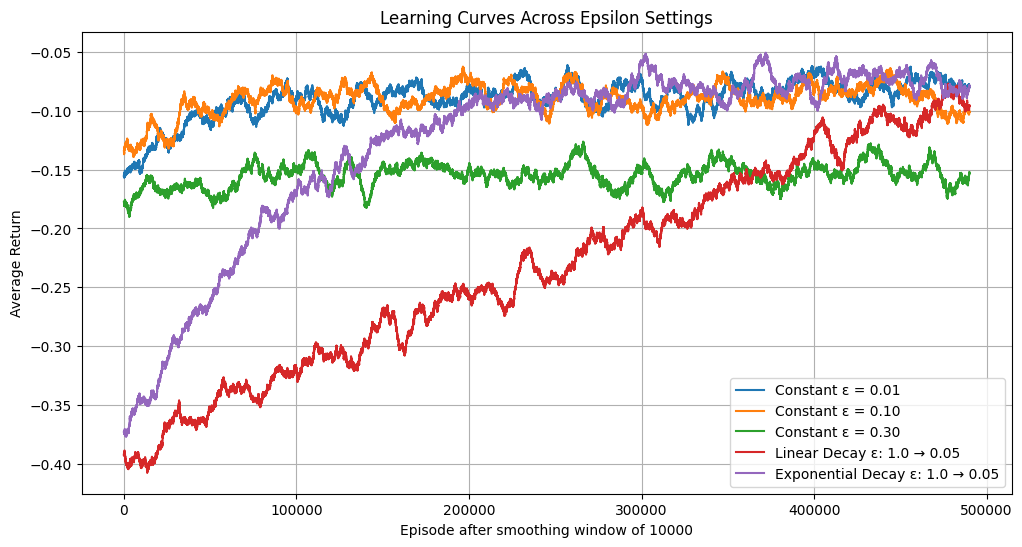

In [34]:
def plot_experiment_learning_curves(experiment_results, window_size=10_000):
    plt.figure(figsize=(12, 6))

    for experiment_name, result in experiment_results.items():
        smoothed = moving_average(result["returns"], window_size)
        plt.plot(smoothed, label=experiment_name)

    plt.title("Learning Curves Across Epsilon Settings")
    plt.xlabel(f"Episode after smoothing window of {window_size}")
    plt.ylabel("Average Return")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_experiment_learning_curves(
    experiment_results,
    window_size=10_000
)

### Summary Table For Epsilon Experiments

In [26]:
def summarize_experiments(experiment_results, last_n=50_000):

    print(f"Average return over last {last_n:,} episodes")
    print("-" * 60)

    for experiment_name, result in experiment_results.items():
        returns = result["returns"]
        final_avg = np.mean(returns[-last_n:])
        win_rate = np.mean(returns[-last_n:] == 1)
        loss_rate = np.mean(returns[-last_n:] == -1)
        draw_rate = np.mean(returns[-last_n:] == 0)

        print(f"{experiment_name}")
        print(f"  Final Avg Return: {final_avg:.4f}")
        print(f"  Win Rate:         {win_rate:.2%}")
        print(f"  Loss Rate:        {loss_rate:.2%}")
        print(f"  Draw Rate:        {draw_rate:.2%}")
        print()


summarize_experiments(experiment_results, last_n=50_000)

Average return over last 50,000 episodes
------------------------------------------------------------
Constant ε = 0.01
  Final Avg Return: -0.0767
  Win Rate:         42.06%
  Loss Rate:        49.73%
  Draw Rate:        8.21%

Constant ε = 0.10
  Final Avg Return: -0.0917
  Win Rate:         41.21%
  Loss Rate:        50.38%
  Draw Rate:        8.41%

Constant ε = 0.30
  Final Avg Return: -0.1542
  Win Rate:         38.78%
  Loss Rate:        54.20%
  Draw Rate:        7.03%

Linear Decay ε: 1.0 → 0.05
  Final Avg Return: -0.1003
  Win Rate:         41.46%
  Loss Rate:        51.49%
  Draw Rate:        7.05%

Exponential Decay ε: 1.0 → 0.05
  Final Avg Return: -0.0755
  Win Rate:         42.54%
  Loss Rate:        50.09%
  Draw Rate:        7.36%



### Plotting Best Experiment's Value Function and Policy

In [31]:
def get_best_experiment_name(experiment_results, last_n=50_000):
    best_name = None
    best_return = -np.inf

    for experiment_name, result in experiment_results.items():
        final_avg = np.mean(result["returns"][-last_n:])

        if final_avg > best_return:
            best_return = final_avg
            best_name = experiment_name

    return best_name, best_return


best_name, best_return = get_best_experiment_name(experiment_results)

print("Best experiment:", best_name)
print("Final average return:", best_return)

best_result = experiment_results[best_name]
best_V = best_result["V"]
best_policy = best_result["policy"]

Best experiment: Exponential Decay ε: 1.0 → 0.05
Final average return: -0.07548


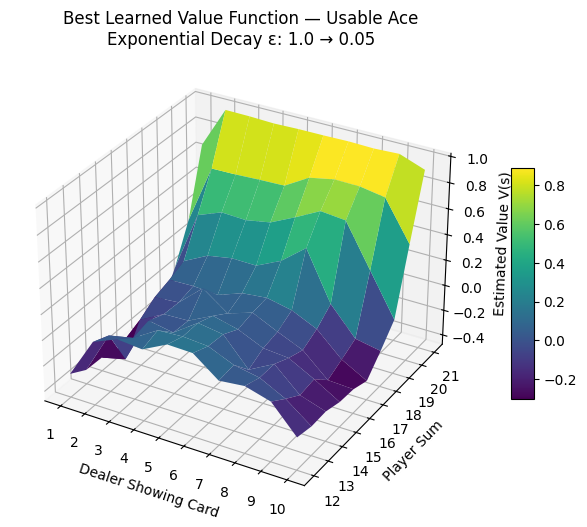

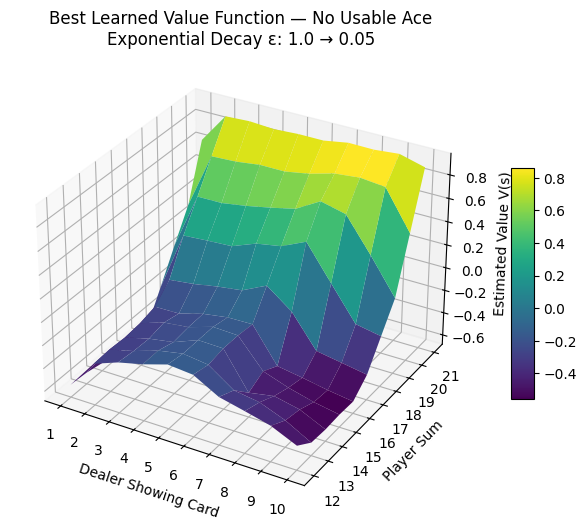

In [32]:
plot_value_surface(
    best_V,
    usable_ace=True,
    title=f"Best Learned Value Function — Usable Ace\n{best_name}"
)

plot_value_surface(
    best_V,
    usable_ace=False,
    title=f"Best Learned Value Function — No Usable Ace\n{best_name}"
)

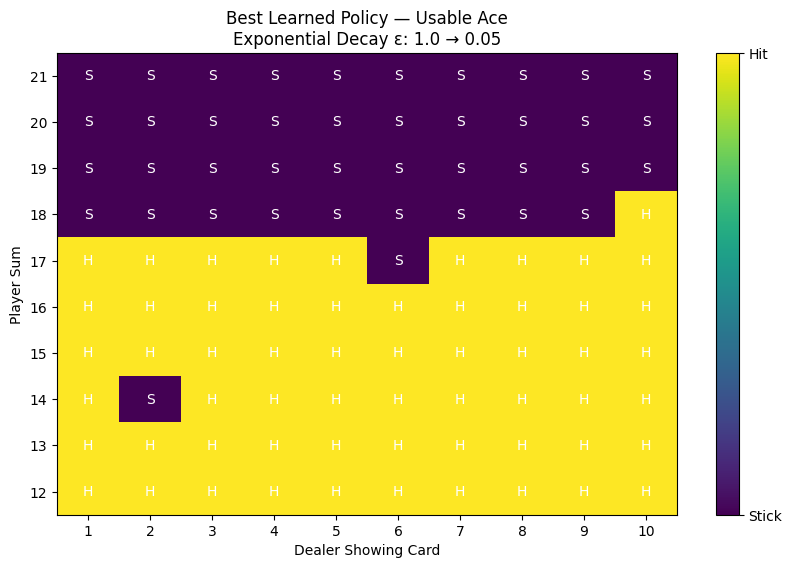

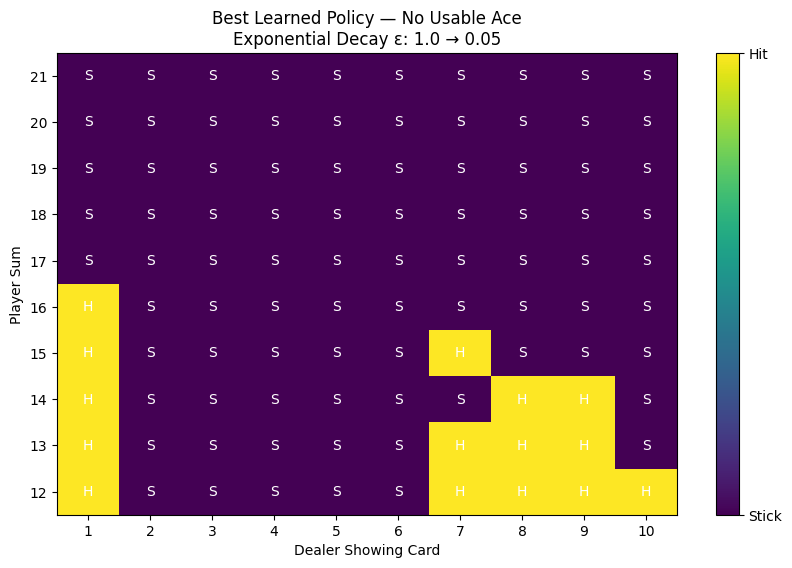

In [29]:
plot_policy(
    best_policy,
    usable_ace=True,
    title=f"Best Learned Policy — Usable Ace\n{best_name}"
)

plot_policy(
    best_policy,
    usable_ace=False,
    title=f"Best Learned Policy — No Usable Ace\n{best_name}"
)

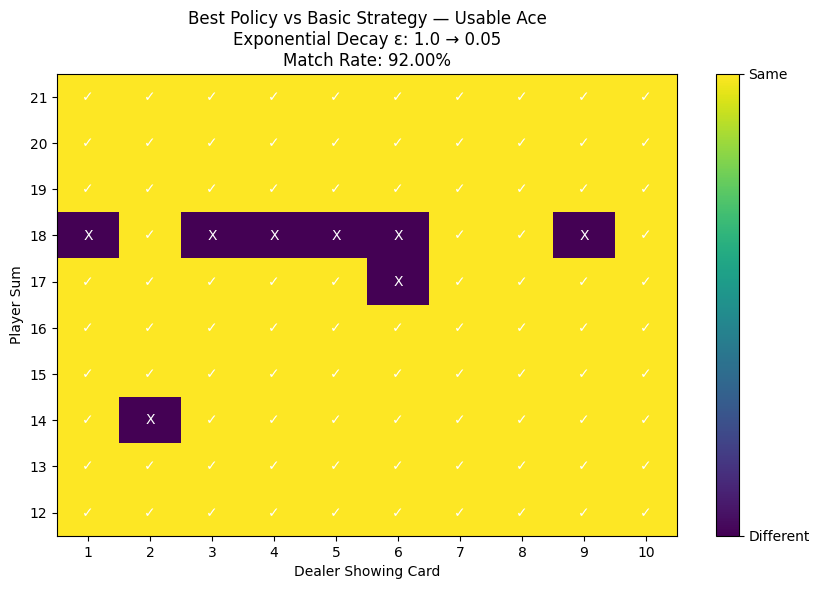

Best Policy vs Basic Strategy — Usable Ace
Exponential Decay ε: 1.0 → 0.05 match rate: 92.00%


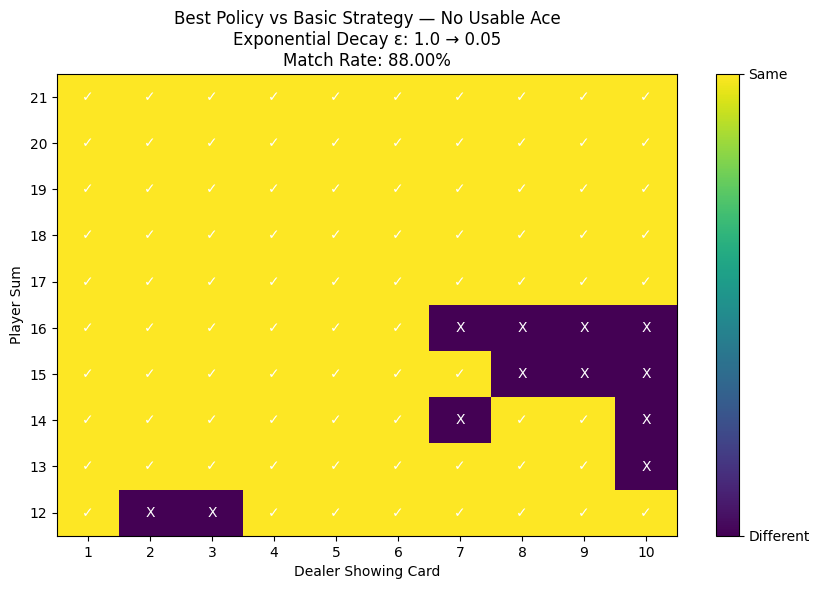

Best Policy vs Basic Strategy — No Usable Ace
Exponential Decay ε: 1.0 → 0.05 match rate: 88.00%


In [30]:
plot_policy_comparison(
    best_policy,
    usable_ace=True,
    title=f"Best Policy vs Basic Strategy — Usable Ace\n{best_name}"
)

plot_policy_comparison(
    best_policy,
    usable_ace=False,
    title=f"Best Policy vs Basic Strategy — No Usable Ace\n{best_name}"
)